# **Embedding Classification**

This work in done by :
- Tejas Phanse
- Jaee Oh
- Mandadi Ayush Reddy

---------

## **Introduction**

This assignment explores text classification using word embeddings. We leverage various embedding techniques such as Word2Vec, TF-IDF, and count vectorization to represent textual data in a numerical format, which enables machine learning models to effectively learn and classify documents. Our analysis focuses on classifying English language web pages based on their metadata and content, employing multiple embedding strategies to identify the most effective approach for this classification task.

### **Set-Up**

This section focuses on loading the data, python libraries (which will be used throughout this notebook)

In [1]:
# Loading Libraries
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder

# Trainging Word2Vec CBOW Model
from gensim.models import Word2Vec

import umap

print("--"*50)
print("Libraries loaded successfully.")
print("--"*50)

/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


----------------------------------------------------------------------------------------------------
Libraries loaded successfully.
----------------------------------------------------------------------------------------------------


In [2]:
# Loading the dataset
data = pd.read_csv("data/english_pages_metadata_clean_with_labels.csv")
print("--"*50)
print("First few Rows of the Dataset:")
print("--"*50)
data

----------------------------------------------------------------------------------------------------
First few Rows of the Dataset:
----------------------------------------------------------------------------------------------------


,page_id,assigned_to,manual_label,manual_label_clean,manual_label_final,full_text,_merge
0,655.0,Vinay Varshigan Sivakumar Jayalakshmi,ecommerce,ECOMMERCE,ECOMMERCE,Fall arrest and work positioning harness – All...,both
1,656.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Vermont Mountain Eats: Jay Peak - All Mountain...,both
2,657.0,Vinay Varshigan Sivakumar Jayalakshmi,news,NEWS,NEWS,05/18/2020 Booking Report for Bulloch County -...,both
3,658.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Is Pickleball Easier than Tennis? | AllRacket\...,both
4,661.0,Vinay Varshigan Sivakumar Jayalakshmi,other,OTHER,OTHER,"Account Executive, Auto Finance - Greater Seat...",both
...,...,...,...,...,...,...,...
591,489.0,Jaee Oh,blog,BLOG,BLOG,Blog post Archives - 38th VoyageMystic Seaport...,both
592,490.0,Jaee Oh,ecommerce,ECOMMERCE,ECOMMERCE,Kids bike pedals collection 3D Model in Bicycl...,both
593,491.0,Jaee Oh,blog,BLOG,BLOG,3patchcrafts: February 2013\n3patchcrafts\nThe...,both
594,493.0,Jaee Oh,other,OTHER,OTHER,Fatal error: Uncaught mysqli_sql_exception: Ta...,both


In [3]:
data_og = pd.read_csv("data/dataset_with_assignments.csv")

analysis_df = data_og[["page_id", "full_text"]].copy()

print("--"*50)
print("First few Rows of the Original Complete Dataset:")
print("--"*50)
analysis_df

----------------------------------------------------------------------------------------------------
First few Rows of the Original Complete Dataset:
----------------------------------------------------------------------------------------------------


,page_id,full_text
0,1,Best Resume Templates 2024 | Ready to Download...
1,4,SH/SZ-HK Stock Connect Quick Quote\n繁\n简\nMark...
2,6,A.D.A. Amiga Demoscene Archive\nA.D.A. Amiga D...
3,7,"Time, Mortality And Memory - blog from trends\..."
4,8,AFR News: JurisDictionary- How Your Constituti...
...,...,...
6309,8259,April 2022 Newsletter – Zettel Family Farms\nS...
6310,8261,PONDS BRIGHT BEAUTY SPOT-LESS GLOW FACEWASH 50...
6311,8262,Understanding Bitcoin And Its Market Trends Ho...
6312,8264,Woman and Dog Wood Figurine | Z Man's Wood Art...


## **Part A) Document-Term Matrix Creation**

Using the techniques from the lab sessions, create a Document-Term Matrix (DTM) with TF-IDF weights for the entire Common Crawl dataset 


### **1. Text Preprocessing**

In this section, the primary focus is on cleaning the text data.Identifying and removing these characters early is important, as they can cause issues later in the pipeline and can negatively impact stability and compatibility. The primary goal here is to retain ASCII characters, such as English letters, numbers, and common punctuation (e.g., '(', ')', '[', ']', '+', '-', ' '), while ensuring that the existing structure of the text remains unchanged.

In [4]:
# list of currency symbols (few of them might not be present, but still we will keep it)
currency_symbols = [
    # Paired (Multi-character) symbols (Longest first)
    'USD','AU$', 'C$', 'NZ$', 'HK$', 'S$', 'US$', 'NT$', 'MX$', 'R$', 'zł', 'Kč','₨',
    'kr', 'Ft', 'ден', 'р.', 'лв', '₡', '₢', '₣', '₥', 

    # Single character symbols (Specific before generic)
    '€', '£', '¥', '元', '₹', '฿', '₩', '₽', '₪', '₺', '₦', '₵', '₫', 
    '₱', '₭', '₮', '₼', '₸', '₴', '៛', '₲', '₡', '₾', '֏', '﷼', 'Ξ', 'Ł', '$'
]

curr_symbols = ''.join(re.escape(s) for s in currency_symbols)

In [5]:
# Text cleaning function
def full_text_clean(text):

    # Regex pattern for extracting emails
    email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'

    # Regex pattern for extracting phone numbers (various formats)
    phone_pattern = r'\b(?:\+\d{1,3}[-\s]?)?(?:\(\d{3}\)|\d{3})[-\s]?\d{3,4}[-\s]\d{4}\b'

    # Regex pattern for extracting dates (various formats)
    date_pattern = r'\b(?:\d{4}[-.]\d{2}[-.]\d{2}|\d{2}[-/]\d{2}[-/]\d{4}|(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec)[a-z]*\s\d{1,2},\s\d{4}|\d{1,2}\s(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec)[a-z]*\.?\s\d{4})\b'

    # Regex pattern for extracting URLs
    url_pattern = r'https?://\S+|www\.\S+'

    # Applying the patterns on the text
    text = re.sub(email_pattern, '', text)
    text = re.sub(phone_pattern, '', text)
    text = re.sub(date_pattern, '', text)
    text = re.sub(url_pattern, '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'[_\-/|]', ' ', text)
    text = text.lower()
    text = re.sub(rf"[^a-z{curr_symbols}\s]", '', text)
    text=re.sub(r'[^\w\s]+', '', text)

    return text

In [6]:
# Data Cleaning and Preprocessing
data['cleaned_text'] = data['full_text'].apply(full_text_clean)
analysis_df['cleaned_text'] = analysis_df['full_text'].apply(full_text_clean)

print("--"*50)
print("Data cleaning and preprocessing completed successfully.")
print("--"*50)
# Displaying the cleaned text
analysis_df[['page_id', 'cleaned_text']]

----------------------------------------------------------------------------------------------------
Data cleaning and preprocessing completed successfully.
----------------------------------------------------------------------------------------------------


,page_id,cleaned_text
0,1,best resume templates ready to download k...
1,4,sh sz hk stock connect quick quote\n\n\nmarket...
2,6,ada amiga demoscene archive\nada amiga demosce...
3,7,time mortality and memory blog from trends\n...
4,8,afr news jurisdictionary how your constitutio...
...,...,...
6309,8259,april newsletter zettel family farms\nskip t...
6310,8261,ponds bright beauty spot less glow facewash g ...
6311,8262,understanding bitcoin and its market trends ho...
6312,8264,woman and dog wood figurine z mans wood art ...


In [7]:
print("--"*50)
print("First few Rows of the Cleaned Text from the Labeled Dataset:")
print("--"*50)
# Displaying the cleaned text
data[['page_id', 'cleaned_text', 'manual_label_final']]

----------------------------------------------------------------------------------------------------
First few Rows of the Cleaned Text from the Labeled Dataset:
----------------------------------------------------------------------------------------------------


,page_id,cleaned_text,manual_label_final
0,655.0,fall arrest and work positioning harness alli...,ECOMMERCE
1,656.0,vermont mountain eats jay peak all mountain ...,BLOG
2,657.0,booking report for bulloch county allongeor...,NEWS
3,658.0,is pickleball easier than tennis allracket\n...,BLOG
4,661.0,account executive auto finance greater seatt...,OTHER
...,...,...,...
591,489.0,blog post archives th voyagemystic seaport\n...,BLOG
592,490.0,kids bike pedals collection d model in bicycle...,ECOMMERCE
593,491.0,patchcrafts february \npatchcrafts\nthe place ...,BLOG
594,493.0,fatal error uncaught mysqli sql exception tabl...,OTHER


In [8]:
idx = np.random.randint(0, 596)
print("--"*50)
print(f"Text Field ({idx}) \n-- Total Characters length before cleaning: {len(data.loc[idx, 'full_text'])} \n-- Total Character Length  after cleaning: {len(data.loc[idx, 'cleaned_text'])}")
print("--"*50)

----------------------------------------------------------------------------------------------------
Text Field (5) 
-- Total Characters length before cleaning: 1653 
-- Total Character Length  after cleaning: 1545
----------------------------------------------------------------------------------------------------


### **2. Removal of Stop Words**

Stop words are high-frequency function words such as “a,” “the,” “he,” and “there” that primarily serve grammatical roles rather than conveying substantial semantic meaning. Because these words appear in nearly every document, they contribute little discriminative information for tasks like text classification. When constructing document representations using techniques such as TF-IDF or bag-of-words models, stop words tend to dominate the feature space due to their high frequency, which can introduce noise and reduce the effectiveness of the representation for distinguishing between classes.

In [9]:
# loading stopwords from both sklearn and nltk
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.corpus import stopwords

nltk_stopwords = set(stopwords.words('english'))
sklearn_stopwords = set(ENGLISH_STOP_WORDS)
nltk_unique = nltk_stopwords.difference(sklearn_stopwords)

# List of common words to be removed from full_text_clean column
common_word_list = {'followers', 'instagram', 'facebook', 'like', 'messages', 'support',
                    'sitemap', 'free', 'faq', 'twitter', 'search', 'subscribe', 'youtube', 
                    'feedback', 'linkedin', 'demo', 'menu', 'following', 'unsubscribe', 
                    'snapchat', 'tiktok', 'whatsapp', '1xbet',
                    'profile', 'share', 'reddit', 'download', 'settings', 'notifications', 'qa', 'people'}

# Common phrases to remove
phrase_list = ["find out more", "join now","terms & conditions", "terms and conditions","all rights reserved","free trial", 
             "click here", "about us", "contact us","terms of service", "privacy policy", "help center", "our story","our team",
             "read more", "learn more", "get started", "download now", "sign up", "log in", 'december december']

stop_words_corpus = sklearn_stopwords.union(nltk_unique).union(common_word_list).union(phrase_list)

print("--"*50)
print("Total Stop Words in the Corpus:", len(stop_words_corpus), "\nSample Stop Words:", list(stop_words_corpus)[:10], "...")
print("--"*50)

----------------------------------------------------------------------------------------------------
Total Stop Words in the Corpus: 449 
Sample Stop Words: ['d', 'instagram', "she'll", 'three', 'thin', 'neither', 'without', 'one', 'me', 'top'] ...
----------------------------------------------------------------------------------------------------


In [10]:
# Stopwords Removal
def remove_stop_words(text):
    clean_text = []
    for word in text.split():
        if word not in stop_words_corpus:
            clean_text.append(word)
    
    return ' '.join(clean_text)

In [11]:
data['stopwords_removed'] = data['cleaned_text'].apply(remove_stop_words)
analysis_df['stopwords_removed'] = analysis_df['cleaned_text'].apply(remove_stop_words)

In [12]:
idx = np.random.randint(0, 596)

print("--"*50)
print(f"Text Field ({idx}) \n-- Total Characters length before cleaning: {len(data.loc[idx, 'full_text'])} \n-- Total Character Length  after cleaning: {len(data.loc[idx, 'cleaned_text'])}")
print("--"*50)

----------------------------------------------------------------------------------------------------
Text Field (162) 
-- Total Characters length before cleaning: 4495 
-- Total Character Length  after cleaning: 4246
----------------------------------------------------------------------------------------------------


In [13]:
print("--"*50)
print(f"Original Text Field ({idx}) \n-- Total Characters length before cleaning: {len(analysis_df.loc[idx, 'full_text'])} \n-- Total Character Length  after cleaning: {len(analysis_df.loc[idx, 'cleaned_text'])}")
print("--"*50)

----------------------------------------------------------------------------------------------------
Original Text Field (162) 
-- Total Characters length before cleaning: 9915 
-- Total Character Length  after cleaning: 9621
----------------------------------------------------------------------------------------------------


In [14]:
sentences = analysis_df['stopwords_removed'].tolist()

# Find total number of tokens
total_tokens = sum(len(s) for s in sentences)

# Find average number of tokens per document
avg_tokens = np.mean([len(s) for s in sentences])

print("--"*50)
print("Preprocessing completed. Sample of cleaned text:")
print("--"*50)
print(f"Total number of tokens in the corpus: {total_tokens}")
print(f"Average number of tokens per document: {avg_tokens}")
print(f"First 5 words in First Document: {sentences[0][:5]}")  # Print first 5 tokens of the first document
print(f"First 5 words in Second Document: {sentences[1][:5]}")  # Print first 5 tokens of the second document

----------------------------------------------------------------------------------------------------
Preprocessing completed. Sample of cleaned text:
----------------------------------------------------------------------------------------------------
Total number of tokens in the corpus: 32300081
Average number of tokens per document: 5115.628919860627
First 5 words in First Document: best 
First 5 words in Second Document: sh sz


### **3. Word2Vec Training**

#### **3.1 Word2Vec Training - CBOW**

In [15]:
complete_corpus = analysis_df['cleaned_text'].str.split().tolist()

> **📌 Note:** In the context of word embedding models such as Word2Vec and FastText, stop word removal is optional rather than strictly necessary. These models rely on contextual co-occurrence patterns and typically incorporate mechanisms such as subsampling of frequent words to reduce the influence of extremely common tokens. However, removing stop words can still be beneficial in domain-specific classification tasks because it reduces training noise and allows the embedding models to focus more on content-bearing words that carry stronger semantic and discriminative signals.

This is the primary reason why we are passing complete document corpus to train our word embedding models

In [16]:
print(len(complete_corpus))
print(complete_corpus[0][:10])  # Print first 10 tokens of the first document in complete corpus

6314
['best', 'resume', 'templates', 'ready', 'to', 'download', 'kickresume', 'we', 'use', 'cookies']


In [17]:
start_time = time.time()

cbow_model = Word2Vec(
    sentences=complete_corpus,
    vector_size=200,   # embedding dimension
    window=5,          # context window
    min_count=10,      # ignore rare words
    workers=4,         # CPU cores
    epochs=10,         # number of training iterations
    sg=0               # CBOW
)
time_cbow = round(time.time() - start_time, 4)

print("--"*50)
print(f"Elapsed time for Word2Vec CBOW: {time_cbow:.4f} seconds")
print("Model Content:", cbow_model)
print("--"*50)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


----------------------------------------------------------------------------------------------------
Elapsed time for Word2Vec CBOW: 18.2697 seconds
Model Content: Word2Vec<vocab=30070, vector_size=200, alpha=0.025>
----------------------------------------------------------------------------------------------------


In [18]:
word_matrix = pd.DataFrame(
    cbow_model.wv.vectors,
    index=cbow_model.wv.index_to_key
)
print("--"*50)
print("First few rows of the Word2Vec CBOW Word Embeddings Matrix:")
print("--"*50)
word_matrix

----------------------------------------------------------------------------------------------------
First few rows of the Word2Vec CBOW Word Embeddings Matrix:
----------------------------------------------------------------------------------------------------


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
the,-1.479617,-1.575531,2.063143,0.729601,-0.389360,-0.190911,1.063455,0.838855,-0.596041,-1.155843,...,0.753517,-1.216392,0.927942,-1.365950,0.994987,-0.750280,0.189539,0.091476,-1.050888,1.245888
and,0.126325,0.022382,-0.547255,0.247059,-0.874894,-0.023375,-0.557509,-0.902786,-0.424080,-0.987924,...,0.063452,-1.436180,0.290441,0.399305,1.308677,-0.528995,0.620265,-0.694035,0.245874,1.556849
to,0.139961,0.774399,0.100272,0.971256,0.405386,0.031921,0.528319,-1.092600,-0.665182,0.025281,...,0.232348,-1.462170,0.305652,0.821191,1.741506,0.003924,0.595529,0.099786,0.738235,2.672072
of,0.800550,-0.878237,0.249032,-0.329219,0.164868,-0.168526,0.479154,-1.532872,-1.758969,-0.079772,...,-0.578150,-0.740081,0.760215,0.056788,1.432217,-1.194067,-0.719830,0.953047,-0.346465,0.698025
a,-1.923743,0.125765,2.764909,0.719050,-0.574260,0.973767,0.045825,-0.377160,0.723131,-1.950368,...,-0.674629,-0.197610,0.255004,0.843280,2.273236,-0.834255,-1.179563,0.915156,-0.505230,1.330557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
warranted,-0.010600,-0.145857,0.140602,0.172042,0.127986,-0.008227,-0.011219,-0.021269,-0.379140,0.217255,...,0.133136,0.035879,-0.085624,0.058401,-0.086463,-0.010952,-0.124862,-0.049958,-0.031052,-0.209220
lows,-0.061286,0.015604,0.020774,0.162384,-0.006890,-0.090231,0.277483,-0.014172,-0.232058,0.082747,...,0.007818,0.015033,-0.050660,0.361614,0.038890,0.071823,-0.064619,-0.026321,-0.014008,-0.007244
boldly,-0.073532,-0.008026,0.017798,0.140836,-0.001119,0.025570,0.015073,-0.087885,-0.012692,0.099965,...,0.060558,0.034347,0.056961,-0.009143,-0.034042,-0.202473,0.005731,0.028130,0.109898,0.168360
endings,0.058719,-0.110853,0.001028,0.079579,-0.011138,-0.139339,-0.072677,-0.037159,-0.233512,0.147236,...,-0.004187,0.032235,-0.072689,0.031116,-0.192289,-0.020298,0.095314,-0.064736,0.166570,-0.010105


#### **3.2 Word2Vec Training - Skipgram**

In [19]:
start_time = time.time()

skipgram_model = Word2Vec(
    sentences=complete_corpus,
    vector_size=200,   # embedding dimension
    window=5,          # context window
    min_count=10,      # ignore rare words
    workers=4,         # CPU cores
    epochs=10,         # number of training iterations
    sg=1               # Skipgram
)
time_sg = round(time.time() - start_time, 4)

print("--"*50)
print(f"Elapsed time for Word2Vec Skipgram: {time_sg:.4f} seconds")
print("Model Content:", skipgram_model)
print("--"*50)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

----------------------------------------------------------------------------------------------------
Elapsed time for Word2Vec Skipgram: 64.8359 seconds
Model Content: Word2Vec<vocab=30070, vector_size=200, alpha=0.025>
----------------------------------------------------------------------------------------------------


In [20]:
word_matrix = pd.DataFrame(
    skipgram_model.wv.vectors,
    index=skipgram_model.wv.index_to_key
)
print("--"*50)
print("First few rows of the Word2Vec Skip-gram Word Embeddings Matrix:")
print("--"*50)
word_matrix

----------------------------------------------------------------------------------------------------
First few rows of the Word2Vec Skip-gram Word Embeddings Matrix:
----------------------------------------------------------------------------------------------------


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
the,0.060745,0.070720,0.107658,0.188557,0.002288,0.033526,0.211445,0.255273,-0.133883,-0.299430,...,0.095108,-0.246396,-0.044626,-0.249807,0.122540,-0.176339,-0.160261,-0.163321,0.064277,0.113856
and,0.232877,-0.033171,0.007908,-0.113954,-0.421067,-0.042123,0.300529,0.050625,-0.086994,-0.204107,...,0.062363,-0.246899,0.164610,-0.114120,0.068899,0.044406,-0.050495,-0.336882,0.011584,0.117370
to,-0.039821,0.024432,-0.042117,0.092825,-0.234160,-0.035795,0.148531,0.037885,-0.018115,-0.124047,...,-0.084974,-0.098189,-0.119827,-0.125597,-0.012957,-0.028474,-0.123543,0.087320,-0.005559,0.340961
of,-0.001284,-0.065534,0.104140,0.168024,-0.122479,0.017912,0.291247,0.139981,-0.186675,-0.017596,...,-0.143537,-0.347196,0.012091,0.024759,0.347512,-0.126174,-0.083681,-0.259871,-0.140504,0.114359
a,0.030315,-0.096988,0.054171,0.132653,0.155366,-0.043308,-0.044930,0.457538,-0.259293,-0.027353,...,-0.138181,-0.093776,-0.146374,-0.044113,-0.198227,-0.058230,-0.360736,0.046343,0.171189,0.143002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
warranted,-0.174020,-0.230276,0.115997,0.078637,-0.034621,0.096287,0.319610,0.159233,-0.188189,0.389540,...,-0.013651,-0.209103,-0.509138,-0.573152,-0.003385,-0.254092,0.044955,0.136940,0.038700,0.043843
lows,-0.130861,-0.005116,0.012391,0.146466,-0.148932,-0.452341,0.594752,-0.020125,-0.377676,-0.167192,...,0.018912,-0.025161,-0.122604,-0.098769,0.182226,-0.037666,-0.180870,0.011533,0.013506,0.168661
boldly,-0.237212,0.152657,-0.245411,0.027398,-0.271009,-0.209631,0.137174,0.016902,-0.228712,0.036080,...,0.144055,-0.295227,0.069812,-0.285476,-0.056624,-0.229548,-0.063584,0.071482,0.390176,0.101844
endings,-0.023007,0.300978,0.044866,0.181510,-0.138966,-0.241993,-0.029651,-0.057666,-0.092346,0.067789,...,0.042155,-0.142709,-0.295201,-0.340450,0.146229,0.071173,-0.096887,-0.061267,0.080039,0.078591


### **4 FastText Training**

In [21]:
from gensim.models import FastText

#### **4.1 Fasttext - CBOW**

In [22]:
start_time = time.time()

ftcbow_model = FastText(
    sentences=complete_corpus,
    vector_size=200,   # embedding dimension
    window=5,          # context window
    min_count=10,      # ignore rare words
    workers=4,         # CPU cores
    epochs=10,         # number of training iterations
    sg=0,              # CBOW
    min_n=3,           # min n-gram length
    max_n=7            # max n-gram length
)
time_ftcbow = round(time.time() - start_time, 4)

print("--"*50)
print(f"Elapsed time for FastText CBOW: {time_ftcbow:.4f} seconds")
print("Model Content:", ftcbow_model)
print("--"*50)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


----------------------------------------------------------------------------------------------------
Elapsed time for FastText CBOW: 100.3829 seconds
Model Content: FastText<vocab=30070, vector_size=200, alpha=0.025>
----------------------------------------------------------------------------------------------------


In [23]:
word_matrix = pd.DataFrame(
    ftcbow_model.wv.vectors,
    index=ftcbow_model.wv.index_to_key
)
print("--"*50)
print("First few rows of the FastText CBOW Word Embeddings Matrix:")
print("--"*50)
word_matrix

----------------------------------------------------------------------------------------------------
First few rows of the FastText CBOW Word Embeddings Matrix:
----------------------------------------------------------------------------------------------------


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
the,-0.746212,0.923106,-2.465345,1.464676,-3.109938,-0.066348,-0.764933,2.174749,1.569922,-2.149916,...,-2.735034,0.422636,-0.576822,0.331525,1.061477,-1.543000,1.949269,0.540685,-0.540760,-0.007067
and,-0.911448,-1.618663,-2.714926,-0.870660,0.974782,0.347054,-2.630184,2.665026,0.228313,3.122341,...,0.531835,4.757541,-2.212236,-0.303973,0.101292,2.136724,-0.896977,-2.266903,0.821348,-0.077929
to,4.630787,3.807099,-4.007451,-5.645218,-4.993084,2.760313,-2.620934,5.034649,3.435354,1.483755,...,0.356147,3.146222,-3.246833,1.740519,5.562262,5.881744,4.525541,-3.671720,2.648646,2.664826
of,0.831752,1.909455,-2.430714,3.837301,-3.193004,4.278661,-0.389716,5.336338,3.578154,-0.047500,...,4.080739,9.339678,1.879213,3.649179,-1.519990,-0.287438,1.324751,-5.809423,-4.565041,-0.455270
a,4.459558,4.033916,-3.971478,1.659364,-7.085317,-9.277372,-5.733677,2.391521,0.792117,-1.090438,...,-9.055008,-3.542446,-15.833586,-2.066148,8.402327,-6.926963,-2.314213,4.935218,-3.469208,5.954749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
warranted,-0.825884,-0.519604,-0.244927,-0.985796,-0.117008,1.455822,1.801993,0.329721,1.126617,0.962295,...,-2.435917,0.474967,0.532687,0.156414,1.107710,1.036911,-0.872319,0.082772,-0.407017,0.180612
lows,1.240956,0.334700,-2.735798,-0.486630,-0.622126,0.438134,0.740327,0.368767,0.301687,0.161861,...,-2.303712,1.446554,-0.453671,1.105328,-0.688195,1.565905,-0.362682,-0.871125,-0.374990,1.294612
boldly,0.357441,-0.162359,-0.417759,0.493104,-0.927714,0.676924,0.462821,0.879639,0.108600,-0.461622,...,0.379246,0.038410,-0.249821,0.574839,0.295838,-0.431076,0.409246,0.529725,-0.415457,0.328475
endings,0.233194,0.240104,0.303050,-1.000579,-0.032577,0.765202,0.802104,0.615330,0.175125,0.756419,...,-0.446605,0.077850,-0.421791,-0.613845,-0.333813,0.370424,-1.427495,-0.423630,0.726440,0.034950


#### **4.2 Fasttext - Skipgrams**

In [24]:
start_time = time.time()

ftskipgram_model = FastText(
    sentences=complete_corpus,
    vector_size=200,   # embedding dimension
    window=5,          # context window
    min_count=10,      # ignore rare words
    workers=4,         # CPU cores
    epochs=10,         # number of training iterations
    sg=1,              # Skip-gram
    min_n=3,           # min n-gram length
    max_n=7            # max n-gram length
)
time_ftskipgram = round(time.time() - start_time, 4)

print("--"*50)
print(f"Elapsed time for FastText Skip-gram: {time_ftskipgram:.4f} seconds")
print("Model Content:", ftskipgram_model)
print("--"*50)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

----------------------------------------------------------------------------------------------------
Elapsed time for FastText Skip-gram: 143.3087 seconds
Model Content: FastText<vocab=30070, vector_size=200, alpha=0.025>
----------------------------------------------------------------------------------------------------


In [25]:
word_matrix = pd.DataFrame(
    ftskipgram_model.wv.vectors,
    index=ftskipgram_model.wv.index_to_key
)
print("--"*50)
print("First few rows of the FastText Skip-gram Word Embeddings Matrix:")
print("--"*50)
word_matrix

----------------------------------------------------------------------------------------------------
First few rows of the FastText Skip-gram Word Embeddings Matrix:
----------------------------------------------------------------------------------------------------


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
the,0.051535,-0.160963,0.181075,-0.028869,0.092571,0.095794,0.149303,-0.066076,-0.202960,-0.215980,...,-0.081680,0.043216,0.020222,0.034622,0.058115,-0.307241,-0.048044,0.008489,0.043855,-0.093203
and,-0.072317,-0.017004,0.045390,-0.055155,-0.045657,0.075027,0.183731,-0.195924,-0.295222,-0.268829,...,-0.029714,0.191059,-0.001398,0.202734,-0.099339,-0.125632,0.005879,0.051645,0.056013,0.171118
to,-0.271507,-0.028224,0.155863,-0.113131,0.069052,0.085676,-0.136771,-0.103813,-0.227436,-0.049314,...,0.025726,0.225349,0.023501,0.028941,-0.059322,-0.098649,0.054623,0.147688,0.139186,0.046640
of,0.067292,0.030503,0.229646,0.035722,-0.023136,-0.015417,0.128873,-0.102925,-0.131272,-0.206381,...,0.160438,0.253671,0.130919,0.107994,-0.119876,-0.166279,-0.030979,-0.011042,0.018713,0.059465
a,-0.025435,-0.012098,0.133471,-0.042436,0.088880,0.041215,-0.138407,0.037897,-0.094478,0.047036,...,0.040477,0.056009,-0.158436,0.081339,-0.026781,-0.069777,-0.029417,-0.004530,0.084445,0.012953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
warranted,-0.307824,-0.026303,0.344922,-0.382416,0.159139,0.116101,-0.315667,0.352355,-0.514159,0.037242,...,-0.120509,0.274088,0.005601,0.067527,0.163972,-0.946263,-0.405987,0.099607,-0.112695,0.172217
lows,0.432529,-0.327532,-0.430167,-0.214063,-0.248486,0.242582,-0.340190,0.270790,-0.012951,0.372802,...,-0.033937,0.138085,-0.300093,0.348072,0.060204,-0.390182,0.265771,-0.283028,-0.042217,0.124986
boldly,0.024694,0.231062,0.241445,-0.032803,0.191945,0.201089,0.032304,0.139172,-0.153700,-0.020795,...,-0.187573,-0.022533,-0.096818,0.200418,-0.068912,-0.095751,-0.042647,0.281438,-0.160825,0.096976
endings,-0.495579,-0.008202,0.082876,-0.124655,0.020457,0.182254,0.271229,-0.183582,0.007932,-0.269420,...,0.328224,-0.239897,0.154180,0.103231,-0.281822,-0.204883,-0.169438,-0.183881,0.086574,-0.274319


### **5. Model Summary**

Here we will see model run-time, vocabulary size and embedding dimensions

In [26]:
# Print vocabulary size and embedding dimensions
training_summary = pd.DataFrame({
    'Model':       ['Word2Vec CBOW', 'Word2Vec Skip-gram', 'FastText CBOW', 'FastText Skip-gram'],
    'Time (s)':    [time_cbow, time_sg, time_ftcbow, time_ftskipgram],
    'Vocab Size':  [len(m.wv) for m in [cbow_model, skipgram_model, ftcbow_model, ftskipgram_model]],
    'Vector Size': [m.vector_size for m in [cbow_model, skipgram_model, ftcbow_model, ftskipgram_model]],
})

print(training_summary)

                Model  Time (s)  Vocab Size  Vector Size
0       Word2Vec CBOW   18.2697       30070          200
1  Word2Vec Skip-gram   64.8359       30070          200
2       FastText CBOW  100.3829       30070          200
3  FastText Skip-gram  143.3087       30070          200


### **6. Semantic Test - Nearest Neighbours**

This section evaluates the quality of trained word embeddings by examining the nearest neighbors of selected words. For each embedding model (Word2Vec CBOW, Word2Vec Skip-gram, FastText CBOW, and FastText Skip-gram), we identify the top 10 most semantically similar words based on cosine distance in the embedding space. This provides insight into whether the models have successfully learned meaningful semantic relationships between words and can identify contextually related terms. We test both domain-specific labels (e.g., ECOMMERCE, GOVERNMENT) and category-relevant keywords to validate the models' understanding of classification semantics.

In [27]:
label_list = data['manual_label_final'].str.lower().unique().tolist()
label_list += ["forum","discussion","document"]

In [28]:
# CBOW Model Semantic Test
for label in label_list:
    print(f"Top 10 similar words to '{label}' in CBOW model:")
    if label in cbow_model.wv:
        similar_words = cbow_model.wv.most_similar(label, topn=10)
        print(similar_words)
    else:
        print(f"  '{label}' not found in CBOW vocabulary.")
    print("--"*50)

Top 10 similar words to 'ecommerce' in CBOW model:
[('shopify', 0.7090624570846558), ('saas', 0.7017532587051392), ('magento', 0.6852397322654724), ('prebuilt', 0.6515857577323914), ('drupal', 0.6486170291900635), ('ux', 0.6379377841949463), ('joomla', 0.6228613257408142), ('elementor', 0.611143946647644), ('prestashop', 0.6110492944717407), ('freelancer', 0.6059557795524597)]
----------------------------------------------------------------------------------------------------
Top 10 similar words to 'blog' in CBOW model:
[('blogs', 0.5818483233451843), ('testimonials', 0.512468695640564), ('faq', 0.5009581446647644), ('faqs', 0.4627857804298401), ('archive', 0.44355738162994385), ('articles', 0.4254252016544342), ('blogging', 0.4221576750278473), ('substack', 0.4180331230163574), ('insider', 0.40775731205940247), ('tutorials', 0.4076555073261261)]
----------------------------------------------------------------------------------------------------
Top 10 similar words to 'news' in CBOW 

In [29]:
# Skipgram Model Semantic Test
for label in label_list:
    print(f"Top 10 similar words to '{label}' in Skipgram model:")
    if label in skipgram_model.wv:
        similar_words = skipgram_model.wv.most_similar(label, topn=10)
        print(similar_words)
    else:
        print(f"  '{label}' not found in Skipgram vocabulary.")
    print("--"*50)

Top 10 similar words to 'ecommerce' in Skipgram model:
[('prestashop', 0.603297770023346), ('drupal', 0.576241135597229), ('bigcommerce', 0.5706862807273865), ('magento', 0.5674743056297302), ('zapier', 0.5631113052368164), ('odoo', 0.5517522692680359), ('shopify', 0.5507286190986633), ('onepage', 0.5419666767120361), ('xero', 0.5394138097763062), ('outsource', 0.5368388891220093)]
----------------------------------------------------------------------------------------------------
Top 10 similar words to 'blog' in Skipgram model:
[('blogs', 0.6645094156265259), ('inboxemail', 0.6126726865768433), ('delegationshared', 0.6009640097618103), ('testimonials', 0.5954768657684326), ('doctena', 0.5938361883163452), ('whitepapers', 0.5923709273338318), ('jtorry', 0.5797927975654602), ('enews', 0.5691735744476318), ('titanfile', 0.5614557862281799), ('mediapost', 0.5415606498718262)]
----------------------------------------------------------------------------------------------------
Top 10 simil

In [30]:
# FastText CBOW Model Semantic Test
for label in label_list:
    print(f"Top 10 similar words to '{label}' in FastText CBOW model:")
    if label in ftcbow_model.wv:
        similar_words = ftcbow_model.wv.most_similar(label, topn=10)
        print(similar_words)
    else:
        print(f"  '{label}' not found in FastText CBOW vocabulary.")
    print("--"*50)

Top 10 similar words to 'ecommerce' in FastText CBOW model:
[('bigcommerce', 0.9470663070678711), ('commerce', 0.9388124346733093), ('woocommerce', 0.9228346347808838), ('commercials', 0.6985480189323425), ('commercialization', 0.697743833065033), ('commercial', 0.6613006591796875), ('commercially', 0.6257346868515015), ('noncommercial', 0.6210354566574097), ('retail', 0.6030024886131287), ('fierce', 0.5925091505050659)]
----------------------------------------------------------------------------------------------------
Top 10 similar words to 'blog' in FastText CBOW model:
[('blogosm', 0.8539401292800903), ('blogs', 0.8522276282310486), ('weblog', 0.8203200697898865), ('blogroll', 0.781286895275116), ('blob', 0.7477458715438843), ('blogger', 0.7307144403457642), ('dlog', 0.7247510552406311), ('vlog', 0.7244102358818054), ('bloglovin', 0.7221871614456177), ('blox', 0.6937933564186096)]
----------------------------------------------------------------------------------------------------


In [31]:
# FastText Skip-gram Model Semantic Test
for label in label_list:
    print(f"Top 10 similar words to '{label}' in FastText Skip-gram model:")
    if label in ftskipgram_model.wv:
        similar_words = ftskipgram_model.wv.most_similar(label, topn=10)
        print(similar_words)
    else:
        print(f"  '{label}' not found in FastText Skip-gram vocabulary.")
    print("--"*50)

Top 10 similar words to 'ecommerce' in FastText Skip-gram model:
[('bigcommerce', 0.9029778242111206), ('commerce', 0.8503264784812927), ('woocommerce', 0.7581245303153992), ('drupal', 0.6462811231613159), ('joomla', 0.5644201636314392), ('sendgrid', 0.5506741404533386), ('onepage', 0.5468549728393555), ('hubspot', 0.5458654761314392), ('magento', 0.5422312021255493), ('wordpress', 0.5395996570587158)]
----------------------------------------------------------------------------------------------------
Top 10 similar words to 'blog' in FastText Skip-gram model:
[('blogs', 0.7385799884796143), ('testimonials', 0.603714108467102), ('blogroll', 0.5974782109260559), ('weblog', 0.5592906475067139), ('testimonies', 0.551414430141449), ('blogosm', 0.5505042672157288), ('jtorry', 0.5497543811798096), ('faq', 0.544415295124054), ('testimonial', 0.5407799482345581), ('newsfeed', 0.5241137742996216)]
--------------------------------------------------------------------------------------------------

### **7. Out of Vocabulary Words (OOV)**

Out-of-Vocabulary (OOV) words are terms that did not appear during model training and therefore lack learned embeddings. This section tests how each embedding model handles OOV words, particularly misspelled or rare variants. Word2Vec models cannot generate vectors for OOV words, resulting in KeyError exceptions when encountered. In contrast, FastText models use character-level n-grams, enabling them to construct approximate embeddings for unseen words based on subword components. This test demonstrates a key advantage of FastText: robustness to spelling variations and rare words that frequently occur in real-world text, making it more practical for production systems where perfect spelling cannot be guaranteed.


In Conclusion:
- Word2Vec limitation: Cannot handle OOV words (raises KeyError)
- FastText advantage: Uses character-level n-grams to construct embeddings for unseen words

In [32]:
# List of misspelled words for OOV testing
oov_test_words = [
    "recieve",      # receive
    "definately",   # definitely
    "seperate",     # separate
    "occured",      # occurred
    "tommorow",     # tomorrow
    "neccessary",   # necessary
    "accomodate",   # accommodate
    "begining",     # beginning
    "restaraunt",   # restaurant
    "embarass"      # embarrass
]

In [33]:
for word in oov_test_words:
    print("\nWord:", word)

    # Word2Vec test
    try:
        print("Word2Vec - CBOW vector exists:", cbow_model.wv.most_similar(word, topn=5))
    except KeyError:
        print("Word2Vec - CBOW: No match for OOV word")

    try:
        print("Word2Vec - Skip-gram vector exists:", skipgram_model.wv.most_similar(word, topn=5))
    except KeyError:
        print("Word2Vec - Skip-gram: No match for OOV word")

    # FastText test
    print("FastText - CBOW vector exists:", ftcbow_model.wv.most_similar(word, topn=5))
    print("FastText - Skip-gram vector exists:", ftskipgram_model.wv.most_similar(word, topn=5))


Word: recieve
Word2Vec - CBOW: No match for OOV word
Word2Vec - Skip-gram: No match for OOV word
FastText - CBOW vector exists: [('rect', 0.7438433766365051), ('relieve', 0.7231568098068237), ('recognise', 0.6959847211837769), ('rec', 0.6880773305892944), ('retrieve', 0.6722366213798523)]
FastText - Skip-gram vector exists: [('rec', 0.6627107262611389), ('reclaim', 0.5357900857925415), ('rect', 0.5351041555404663), ('recycle', 0.519123375415802), ('forgive', 0.5141055583953857)]

Word: definately
Word2Vec - CBOW: No match for OOV word
Word2Vec - Skip-gram: No match for OOV word
FastText - CBOW vector exists: [('unfortunately', 0.7741457223892212), ('desperately', 0.7680163979530334), ('wisely', 0.7216012477874756), ('definitely', 0.7178542613983154), ('deliberately', 0.7089073657989502)]
FastText - Skip-gram vector exists: [('fortunately', 0.6649131178855896), ('unfortunately', 0.6643316149711609), ('definable', 0.6520013809204102), ('desperately', 0.6439810395240784), ('deliberately'

In [34]:
# Define query words for each categories
categories = {
    'ECOMMERCE':  ['price', 'product', 'shipping'],
    'GOVERNMENT': ['legislation', 'regulation', 'official'],
    'TECHNICAL':  ['software', 'hardware', 'development'],
    'NEWS':       ['report', 'news', 'coverage'],
    'BLOG':       ['comment', 'blog', 'post'],
    'EDUCATIONAL':['student', 'curriculum', 'academic'],
    'OTHER' :     ['contact', 'event', 'forum'] # OTHER category is expected to be noisy since it is any generic document that doesn't fit the above.
}

for category, query_words in categories.items():
    print(f"\nCategory: {category}")
    for word in query_words:
        print(f"\nQuery Word: '{word}'")

        # Word2Vec test
        try:
            print("Word2Vec - CBOW vector:", cbow_model.wv.most_similar(word, topn=5))
        except KeyError:
            print("Word2Vec - CBOW: No match for OOV word")

        try:
            print("Word2Vec - Skip-gram vector:", skipgram_model.wv.most_similar(word, topn=5))
        except KeyError:
            print("Word2Vec - Skip-gram: No match for OOV word")
        
        # FastText test
        print("FastText - CBOW vector:", ftcbow_model.wv.most_similar(word, topn=5))
        print("FastText - Skip-gram vector:", ftskipgram_model.wv.most_similar(word, topn=5))
    print("--"*50)



Category: ECOMMERCE

Query Word: 'price'
Word2Vec - CBOW vector: [('msrp', 0.5248711109161377), ('prices', 0.495137095451355), ('quantity', 0.41981643438339233), ('qty', 0.41705021262168884), ('lowest', 0.3894834518432617)]
Word2Vec - Skip-gram vector: [('rrp', 0.5806563496589661), ('pidilite', 0.5487615466117859), ('lowest', 0.5318090319633484), ('uom', 0.5266266465187073), ('containersapprox', 0.5246744155883789)]
FastText - CBOW vector: [('ecprice', 0.945213258266449), ('pricehk', 0.9274216294288635), ('pricec', 0.9195795655250549), ('priceus', 0.900802493095398), ('pricer', 0.8823238611221313)]
FastText - Skip-gram vector: [('priceus', 0.7574944496154785), ('pricehk', 0.7554108500480652), ('pricer', 0.7416642904281616), ('highprice', 0.7303299903869629), ('priced', 0.7018561363220215)]

Query Word: 'product'
Word2Vec - CBOW vector: [('products', 0.492118775844574), ('item', 0.4661083221435547), ('brand', 0.4272453784942627), ('specification', 0.4188901484012604), ('category', 0.40

### **8. Visualization of CBOW from Word2Vec and FastText**

/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


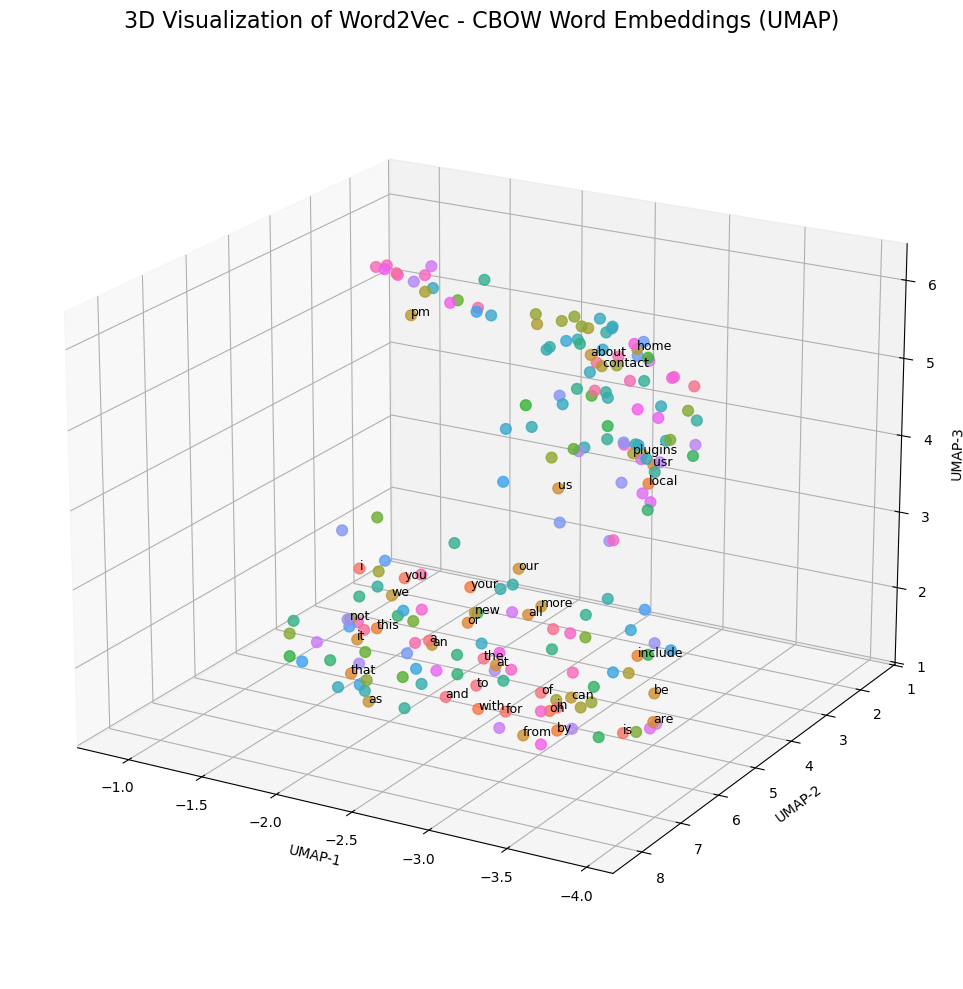

In [35]:
words = list(cbow_model.wv.index_to_key[:200])
vectors = cbow_model.wv[words]

# UMAP dimensionality reduction
umap_model = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

coords = umap_model.fit_transform(vectors)

# Color palette
palette = sns.color_palette("husl", len(words))

# Create 3D plot
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(
    coords[:,0],
    coords[:,1],
    coords[:,2],
    c=palette,
    s=60,
    alpha=0.8
)

# Annotate a subset to avoid clutter
for i, word in enumerate(words[:40]):
    ax.text(
        coords[i,0],
        coords[i,1],
        coords[i,2],
        word,
        fontsize=9
    )

# Axis labels
ax.set_title("3D Visualization of Word2Vec - CBOW Word Embeddings (UMAP)", fontsize=16)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_zlabel("UMAP-3")

# Improve viewing angle
ax.view_init(elev=20, azim=120)

plt.tight_layout()
plt.show()

/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


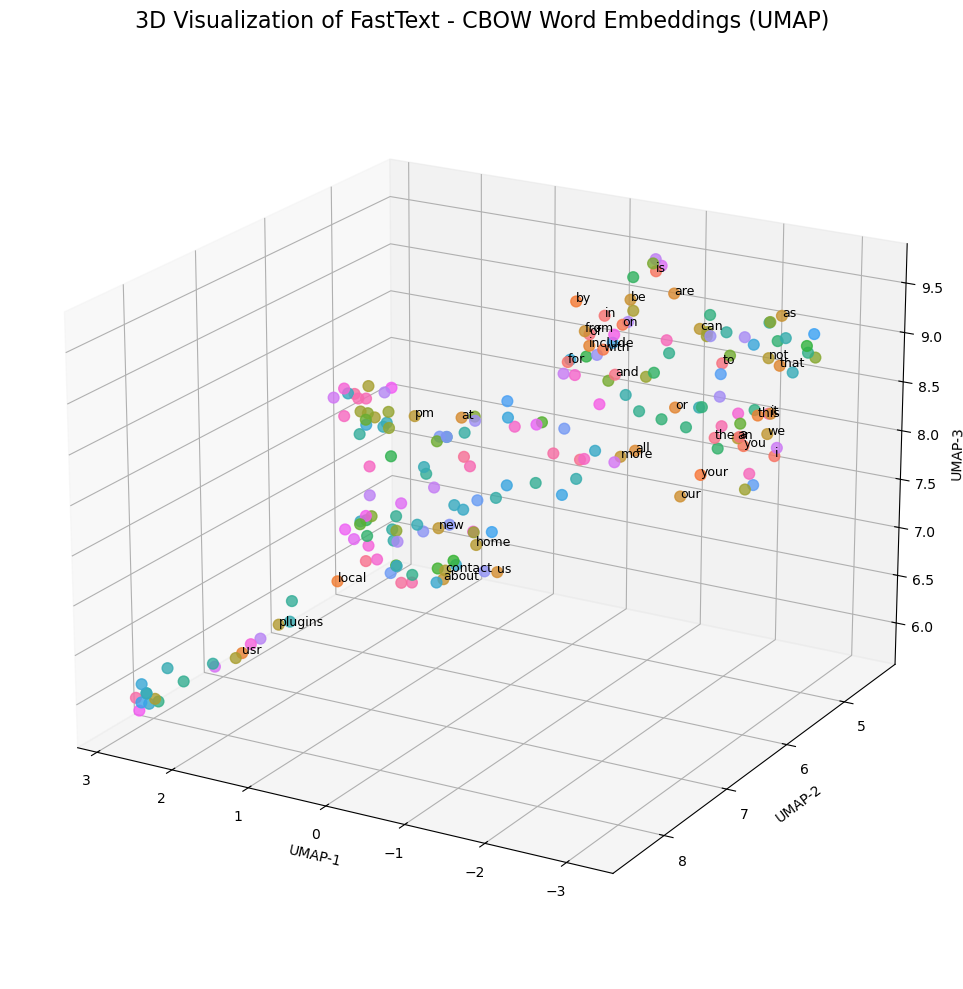

In [36]:
words = list(ftcbow_model.wv.index_to_key[:200])
vectors = ftcbow_model.wv[words]

# UMAP dimensionality reduction
umap_model = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

coords = umap_model.fit_transform(vectors)

# Color palette
palette = sns.color_palette("husl", len(words))

# Create 3D plot
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(
    coords[:,0],
    coords[:,1],
    coords[:,2],
    c=palette,
    s=60,
    alpha=0.8
)

# Annotate a subset to avoid clutter
for i, word in enumerate(words[:40]):
    ax.text(
        coords[i,0],
        coords[i,1],
        coords[i,2],
        word,
        fontsize=9
    )

# Axis labels
ax.set_title("3D Visualization of FastText - CBOW Word Embeddings (UMAP)", fontsize=16)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_zlabel("UMAP-3")

# Improve viewing angle
ax.view_init(elev=20, azim=120)

plt.tight_layout()
plt.show()

## **Part B) Document Embedding & Classification**

This section transitions from word-level embeddings to document-level representations and applies classification algorithms. The workflow includes: 
- (1) constructing TF-IDF matrices to capture term importance and document-term relationships, 
- (2) aggregating trained word embeddings (from Word2Vec and FastText models) into document vectors using simple mean and weighted averaging techniques, 
- (3) training and comparing classification models (Random Forest and XGBoost) using these document representations, and 
- (4) applying the best-performing model to predict categories for unlabeled web pages in the complete dataset. 

The goal is to evaluate which embedding approach combined with which classifier achieves optimal document classification performance.

#### **1. TFIDF-Matrix Construction of Labeled Data**

In [37]:
# Defininfg TFIDF Vectorizer
vectorizer = TfidfVectorizer( 
    max_features= 6000,      # total features, NOT per document
    ngram_range=(1, 2),      # unigrams + bigrams
    max_df=0.50,             # ignore very common words
    min_df=3                 # ignore rare noise
)

In [38]:
# Text Transformation using TFIDF Vectorizer
tfidf_matrix = vectorizer.fit_transform(data['stopwords_removed'])

In [39]:
print("--"*50)
print("Shape of the TFIDF matrix: (Rows, Columns)")
print("--"*50)  
print(tfidf_matrix.shape)
matrix_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("--"*50)
print("TFIDF Matrix as a DataFrame:")
print("--"*50)
matrix_df

----------------------------------------------------------------------------------------------------
Shape of the TFIDF matrix: (Rows, Columns)
----------------------------------------------------------------------------------------------------
(596, 6000)
----------------------------------------------------------------------------------------------------
TFIDF Matrix as a DataFrame:
----------------------------------------------------------------------------------------------------


,aa,ab,ability,able,abs,absolute,absolutely,absolutely essential,abstract,abu,...,лв,ле,лн,не,нр,рд,ре,редв,рер,рн
0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.000000,0.017473,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.025342,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
592,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.005547
593,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
594,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


### **2. Using Trained Eembedding Models on Label Corpus**

**Simple Mean**

In [40]:
def document_vector(model, document):

    mean_vec = np.zeros(model.vector_size)

    word_vectors = [
        model.wv[word]
        for word in document
        if word in model.wv
    ]

    if len(word_vectors) == 0:
        mean_vec = np.zeros(model.vector_size)
    else:
        mean_vec = np.mean(word_vectors, axis=0)

    return mean_vec

**Weighted Average**

In [41]:
def weight_avg(doc_vec, tfidf_vec):
    vec_list = []
    doc_vec_mean = np.mean(doc_vec)
    for i in range(len(tfidf_vec)):
        vec_list.append(doc_vec_mean * tfidf_vec[i])
    
    return vec_list

**Word2Vec - CBOW**

In [42]:
data['doc_vector'] = data['stopwords_removed'].apply(
    lambda text: document_vector(cbow_model, text.split())
)

print("--"*50)
print("Document vectors generated successfully. Sample vector for the first document:")
print("--"*50)
data[['page_id', 'stopwords_removed', 'doc_vector', 'manual_label_final']]

----------------------------------------------------------------------------------------------------
Document vectors generated successfully. Sample vector for the first document:
----------------------------------------------------------------------------------------------------


,page_id,stopwords_removed,doc_vector,manual_label_final
0,655.0,fall arrest work positioning harness allied sa...,"[-0.019665912, -0.09548356, -0.043961108, -0.0...",ECOMMERCE
1,656.0,vermont mountain eats jay peak mountain mamas ...,"[0.038862668, -0.034667313, 0.09784203, 0.2967...",BLOG
2,657.0,booking report bulloch county allongeorgia geo...,"[-0.101462655, 0.25804213, 0.20232233, 0.61773...",NEWS
3,658.0,pickleball easier tennis allracket skip conten...,"[0.006228757, -0.2979941, 0.20620714, 0.116096...",BLOG
4,661.0,account executive auto finance greater seattle...,"[0.14894003, -0.09882535, 0.19306308, 0.294176...",OTHER
...,...,...,...,...
591,489.0,blog post archives th voyagemystic seaport th ...,"[0.035810437, 0.104038574, 0.28207037, 0.33646...",BLOG
592,490.0,kids bike pedals collection model bicycle dexp...,"[-0.13745818, -0.026046062, -0.08677356, -0.09...",ECOMMERCE
593,491.0,patchcrafts february patchcrafts place works c...,"[-0.116727166, -0.09063708, 0.24362244, 0.2281...",BLOG
594,493.0,fatal error uncaught mysqli sql exception tabl...,"[-0.56096405, -0.5437371, 0.1904585, -0.159388...",OTHER


In [43]:
col_list = matrix_df.columns
cbow_matrix = []

for indx in range(len(data)):
    doc_vec = data.loc[indx, 'doc_vector']
    tfidf_vec = matrix_df.loc[indx].values
    weighted_avg = weight_avg(doc_vec, tfidf_vec)

    cbow_matrix.append(weighted_avg)

cbow_matrix_df = pd.DataFrame(cbow_matrix, columns=col_list)

cbow_matrix_df['Category'] = data['manual_label_final'].values

print("--"*50)
print("CBOW Weighted Average Matrix as a DataFrame:")
print("--"*50)
cbow_matrix_df

----------------------------------------------------------------------------------------------------
CBOW Weighted Average Matrix as a DataFrame:
----------------------------------------------------------------------------------------------------


,aa,ab,ability,able,abs,absolute,absolutely,absolutely essential,abstract,abu,...,ле,лн,не,нр,рд,ре,редв,рер,рн,Category
0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,ECOMMERCE
1,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
2,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NEWS
3,0.0,0.0,0.00000,0.000498,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
4,0.0,0.0,0.00076,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,OTHER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
592,-0.0,-0.0,-0.00000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000018,ECOMMERCE
593,-0.0,-0.0,-0.00000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,BLOG
594,-0.0,-0.0,-0.00000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,OTHER


**Word2Vec - SkipGram**

In [44]:
data['doc_vector'] = data['stopwords_removed'].apply(
    lambda text: document_vector(skipgram_model, text.split())
)

print("--"*50)
print("Document vectors generated successfully. Sample vector for the first document:")
print("--"*50)
data[['page_id', 'stopwords_removed', 'doc_vector', 'manual_label_final']]

----------------------------------------------------------------------------------------------------
Document vectors generated successfully. Sample vector for the first document:
----------------------------------------------------------------------------------------------------


,page_id,stopwords_removed,doc_vector,manual_label_final
0,655.0,fall arrest work positioning harness allied sa...,"[0.01758123, -0.08216417, -0.08362061, 0.18482...",ECOMMERCE
1,656.0,vermont mountain eats jay peak mountain mamas ...,"[0.048935376, 0.055499624, -0.038257997, 0.195...",BLOG
2,657.0,booking report bulloch county allongeorgia geo...,"[-0.15723705, 0.06061833, -0.007383822, 0.3035...",NEWS
3,658.0,pickleball easier tennis allracket skip conten...,"[0.0015554546, 0.042907555, 0.012712932, 0.136...",BLOG
4,661.0,account executive auto finance greater seattle...,"[-0.0026417526, 0.03739958, -0.008630235, 0.22...",OTHER
...,...,...,...,...
591,489.0,blog post archives th voyagemystic seaport th ...,"[0.029952839, 0.06955649, -0.014888825, 0.1489...",BLOG
592,490.0,kids bike pedals collection model bicycle dexp...,"[-0.088494465, 0.14190948, 0.10668565, 0.05085...",ECOMMERCE
593,491.0,patchcrafts february patchcrafts place works c...,"[0.041618746, -0.0053381748, 0.027899101, 0.20...",BLOG
594,493.0,fatal error uncaught mysqli sql exception tabl...,"[-0.16183911, -0.17809601, 0.08181738, -0.0877...",OTHER


In [45]:
col_list = matrix_df.columns
skipgram_matrix = []

for indx in range(len(data)):
    doc_vec = data.loc[indx, 'doc_vector']
    tfidf_vec = matrix_df.loc[indx].values
    weighted_avg = weight_avg(doc_vec, tfidf_vec)

    skipgram_matrix.append(weighted_avg)

skipgram_matrix_df = pd.DataFrame(skipgram_matrix, columns=col_list)

skipgram_matrix_df['Category'] = data['manual_label_final'].values

print("--"*50)
print("Skip-gram Weighted Average Matrix as a DataFrame:")
print("--"*50)
skipgram_matrix_df

----------------------------------------------------------------------------------------------------
Skip-gram Weighted Average Matrix as a DataFrame:
----------------------------------------------------------------------------------------------------


,aa,ab,ability,able,abs,absolute,absolutely,absolutely essential,abstract,abu,...,ле,лн,не,нр,рд,ре,редв,рер,рн,Category
0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,ECOMMERCE
1,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,BLOG
2,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NEWS
3,0.0,0.0,0.000000,0.000012,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
4,0.0,0.0,0.000118,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,OTHER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
592,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000006,ECOMMERCE
593,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,BLOG
594,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,OTHER


**FastText - CBOW**

In [46]:
data['doc_vector'] = data['stopwords_removed'].apply(
    lambda text: document_vector(ftcbow_model, text.split())
)

print("--"*50)
print("Document vectors generated successfully. Sample vector for the first document:")
print("--"*50)
data[['page_id', 'stopwords_removed', 'doc_vector', 'manual_label_final']]

----------------------------------------------------------------------------------------------------
Document vectors generated successfully. Sample vector for the first document:
----------------------------------------------------------------------------------------------------


,page_id,stopwords_removed,doc_vector,manual_label_final
0,655.0,fall arrest work positioning harness allied sa...,"[0.18513839, -0.20784254, -0.49683517, -0.2562...",ECOMMERCE
1,656.0,vermont mountain eats jay peak mountain mamas ...,"[0.000547141, -0.17700797, -0.13348086, -0.123...",BLOG
2,657.0,booking report bulloch county allongeorgia geo...,"[0.38466462, 0.6316791, -0.62729466, -0.410905...",NEWS
3,658.0,pickleball easier tennis allracket skip conten...,"[0.59794873, -0.39236832, -0.67178243, 0.22712...",BLOG
4,661.0,account executive auto finance greater seattle...,"[0.2560974, 0.064658195, -0.9936095, -0.557334...",OTHER
...,...,...,...,...
591,489.0,blog post archives th voyagemystic seaport th ...,"[0.0007302895, 0.08556338, 0.07640608, 0.00418...",BLOG
592,490.0,kids bike pedals collection model bicycle dexp...,"[0.15735051, -0.5121284, -0.14725287, -0.24079...",ECOMMERCE
593,491.0,patchcrafts february patchcrafts place works c...,"[0.14040968, -0.46033156, 0.17588882, 0.122334...",BLOG
594,493.0,fatal error uncaught mysqli sql exception tabl...,"[-0.10829938, 0.8329829, 0.4681526, -0.2672120...",OTHER


In [47]:
col_list = matrix_df.columns
ftcbow_matrix = []

for indx in range(len(data)):
    doc_vec = data.loc[indx, 'doc_vector']
    tfidf_vec = matrix_df.loc[indx].values
    weighted_avg = weight_avg(doc_vec, tfidf_vec)

    ftcbow_matrix.append(weighted_avg)

ftcbow_matrix_df = pd.DataFrame(ftcbow_matrix, columns=col_list)

ftcbow_matrix_df['Category'] = data['manual_label_final'].values

print("--"*50)
print("FastText-CBOW Weighted Average Matrix as a DataFrame:")
print("--"*50)
ftcbow_matrix_df

----------------------------------------------------------------------------------------------------
FastText-CBOW Weighted Average Matrix as a DataFrame:
----------------------------------------------------------------------------------------------------


,aa,ab,ability,able,abs,absolute,absolutely,absolutely essential,abstract,abu,...,ле,лн,не,нр,рд,ре,редв,рер,рн,Category
0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,ECOMMERCE
1,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
2,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NEWS
3,0.0,0.0,0.000000,0.001378,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
4,0.0,0.0,0.001434,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,OTHER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
592,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000426,ECOMMERCE
593,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
594,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,OTHER


**FastText - SkipGram**

In [48]:
data['doc_vector'] = data['stopwords_removed'].apply(
    lambda text: document_vector(ftskipgram_model, text.split())
)

print("--"*50)
print("Document vectors generated successfully. Sample vector for the first document:")
print("--"*50)
data[['page_id', 'stopwords_removed', 'doc_vector', 'manual_label_final']]

----------------------------------------------------------------------------------------------------
Document vectors generated successfully. Sample vector for the first document:
----------------------------------------------------------------------------------------------------


,page_id,stopwords_removed,doc_vector,manual_label_final
0,655.0,fall arrest work positioning harness allied sa...,"[0.091033205, -0.13270113, 0.2725479, -0.07226...",ECOMMERCE
1,656.0,vermont mountain eats jay peak mountain mamas ...,"[0.07363451, -0.08134625, 0.39457706, -0.06385...",BLOG
2,657.0,booking report bulloch county allongeorgia geo...,"[0.014392335, -0.029817197, 0.40608427, -0.042...",NEWS
3,658.0,pickleball easier tennis allracket skip conten...,"[0.07593346, -0.045196526, 0.18428291, -0.1948...",BLOG
4,661.0,account executive auto finance greater seattle...,"[0.017737092, -0.07102454, 0.2980091, -0.07634...",OTHER
...,...,...,...,...
591,489.0,blog post archives th voyagemystic seaport th ...,"[-0.0040829326, -0.037097577, 0.3627733, -0.02...",BLOG
592,490.0,kids bike pedals collection model bicycle dexp...,"[-0.03380317, -0.03281911, 0.12625498, -0.0859...",ECOMMERCE
593,491.0,patchcrafts february patchcrafts place works c...,"[0.056807447, -0.09700885, 0.23806606, -0.0816...",BLOG
594,493.0,fatal error uncaught mysqli sql exception tabl...,"[0.065362096, -0.0367324, 0.6188381, -0.037061...",OTHER


In [49]:
col_list = matrix_df.columns
ftskipgram_matrix = []

for indx in range(len(data)):
    doc_vec = data.loc[indx, 'doc_vector']
    tfidf_vec = matrix_df.loc[indx].values
    weighted_avg = weight_avg(doc_vec, tfidf_vec)

    ftskipgram_matrix.append(weighted_avg)

ftskipgram_matrix_df = pd.DataFrame(ftskipgram_matrix, columns=col_list)

ftskipgram_matrix_df['Category'] = data['manual_label_final'].values

print("--"*50)
print("FastText-Skip-gram Weighted Average Matrix as a DataFrame:")
print("--"*50)
ftskipgram_matrix_df

----------------------------------------------------------------------------------------------------
FastText-Skip-gram Weighted Average Matrix as a DataFrame:
----------------------------------------------------------------------------------------------------


,aa,ab,ability,able,abs,absolute,absolutely,absolutely essential,abstract,abu,...,ле,лн,не,нр,рд,ре,редв,рер,рн,Category
0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,ECOMMERCE
1,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
2,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NEWS
3,0.0,0.0,0.000000,0.000184,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
4,0.0,0.0,0.000049,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,OTHER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
592,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000054,ECOMMERCE
593,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
594,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,OTHER


### **3. Classification - Train and Compare Random Forest and XGBoost**

In [50]:
# Defining train test libraries
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [51]:
# Train models
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [52]:
results_summary = pd.DataFrame({
    'EmbeddingModel': [],
    'Model': [],
    'Accuracy': [],  # Placeholder for accuracy scores
    'CV Mean Accuracy': [],  # Placeholder for cross-validation mean accuracy
    'CV Std': [],  # Placeholder for cross-validation standard deviation
    'Precision': [],  # Placeholder for precision scores
    'Recall': [],  # Placeholder for recall scores
    'F1-Score': []  # Placeholder for F1 scores
})

summary = []

for embedding in ["Word2Vec-CBOW", "Word2Vec Skip-gram", "FastText-CBOW", "FastText Skip-gram"]:
    for model_name, model in [("Random Forest", rf), ("XGBoost", xgb)]:
        if embedding == "Word2Vec-CBOW":
            matrix_df = cbow_matrix_df
        elif embedding == "Word2Vec Skip-gram":
            matrix_df = skipgram_matrix_df
        elif embedding == "FastText-CBOW":
            matrix_df = ftcbow_matrix_df
        else:
            matrix_df = ftskipgram_matrix_df
        
        print("--"*50)
        print(f"Training {model_name} with {embedding} embeddings...")

        X = matrix_df.drop(columns=['Category'])
        
        if model_name == "XGBoost":
            le = LabelEncoder()
            y = le.fit_transform(matrix_df['Category'])
        else:
            y = matrix_df['Category']
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Perform cross-validation
        kfold = KFold(n_splits=10, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

        cv_mean = scores.mean()
        cv_std  = scores.std()

        report = classification_report(y_test, y_pred, output_dict=True)['weighted avg']

        summary.append({
            'EmbeddingModel': embedding,
            'Model': model_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'CV Mean Accuracy': cv_mean,
            'CV Std': cv_std,
            'Precision': report['precision'],
            'Recall': report['recall'],
            'F1-Score': report['f1-score']
        })

results_summary = pd.DataFrame(summary)
print("--"*50)
print("Model Evaluation Summary:")
print("--"*50)
print(results_summary)

----------------------------------------------------------------------------------------------------
Training Random Forest with Word2Vec-CBOW embeddings...


/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

----------------------------------------------------------------------------------------------------
Training XGBoost with Word2Vec-CBOW embeddings...


/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

----------------------------------------------------------------------------------------------------
Training Random Forest with Word2Vec Skip-gram embeddings...


...

/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

----------------------------------------------------------------------------------------------------
Training Random Forest with FastText Skip-gram embeddings...


/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

----------------------------------------------------------------------------------------------------
Training XGBoost with FastText Skip-gram embeddings...
----------------------------------------------------------------------------------------------------
Model Evaluation Summary:
----------------------------------------------------------------------------------------------------
       EmbeddingModel          Model  Accuracy  CV Mean Accuracy    CV Std  \
0       Word2Vec-CBOW  Random Forest  0.508333          0.511836  0.066595   
1       Word2Vec-CBOW        XGBoost  0.508333          0.522006  0.077423   
2  Word2Vec Skip-gram  Random Forest  0.508333          0.494859  0.048661   
3  Word2Vec Skip-gram        XGBoost  0.483333          0.526864  0.056857   
4       FastText-CBOW  Random Forest  0.550000          0.548814  0.064466   
5       FastText-CBOW        XGBoost  0.550000          0.535480  0.054164   
6  FastText Skip-gram  Random Forest  0.525000          0.530480  0.06

/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

The output is a comprehensive comparison table evaluating 8 different model combinations (4 embedding types × 2 classifiers: Random Forest and XGBoost). Each row represents a unique configuration evaluated on:

- **Accuracy**: Test set accuracy—the proportion of correctly classified documents
- **CV Mean Accuracy**: Mean accuracy across 10-fold cross-validation, indicating average generalization performance
- **CV Std**: Standard deviation of cross-validation scores, measuring stability and variability across folds
- **Precision, Recall, F1-Score**: Weighted averages over all classes, assessing overall classification quality

The table enables systematic comparison to identify the best performing embedding-classifier pair for document classification. Based on this analysis, **XGBoost with FastText-CBOW embeddings** achieves the best balance of metrics (Accuracy = 0.53, Precision = 0.550, F1-Score = 0.53), balancing predictive accuracy with robustness across all document categories.

### **4. Prediction**
Apply best-performing model to predict categories for all unlabeled web pages.

**Constructing TF-IDF Matrix for Complete data**

In [53]:
complete_tfidf_matrix = vectorizer.transform(analysis_df['stopwords_removed'])

In [54]:
print("--"*50)
print("Shape of the TFIDF matrix: (Rows, Columns)")
print("--"*50)  
print(complete_tfidf_matrix.shape)
complete_tfidf_matrix_df = pd.DataFrame(complete_tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("--"*50)
print("TFIDF Matrix as a DataFrame:")
print("--"*50)
complete_tfidf_matrix_df

----------------------------------------------------------------------------------------------------
Shape of the TFIDF matrix: (Rows, Columns)
----------------------------------------------------------------------------------------------------
(6314, 6000)
----------------------------------------------------------------------------------------------------
TFIDF Matrix as a DataFrame:
----------------------------------------------------------------------------------------------------


,aa,ab,ability,able,abs,absolute,absolutely,absolutely essential,abstract,abu,...,лв,ле,лн,не,нр,рд,ре,редв,рер,рн
0,0.000000,0.000000,0.0,0.005292,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.055717,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.0,0.009016,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.010908,0.0,0.030303,0.0,0.010136,0.008311,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6309,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6310,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6311,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6312,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
analysis_df['doc_vector'] = analysis_df['stopwords_removed'].apply(
    lambda text: document_vector(ftcbow_model, text.split())
)

print("--"*50)
print("Document vectors generated successfully. Sample vector for the first document:")
print("--"*50)
analysis_df[['page_id', 'stopwords_removed', 'doc_vector']]

----------------------------------------------------------------------------------------------------
Document vectors generated successfully. Sample vector for the first document:
----------------------------------------------------------------------------------------------------


,page_id,stopwords_removed,doc_vector
0,1,best resume templates ready kickresume use coo...,"[0.34272146, -0.108883835, -0.5645052, -0.2713..."
1,4,sh sz hk stock connect quick quote market ipho...,"[-0.055425137, 0.17677456, -0.5663097, -0.4750..."
2,6,ada amiga demoscene archive ada amiga demoscen...,"[-0.12262205, -0.010293587, -0.25789836, -0.40..."
3,7,time mortality memory blog trends wikidotcom w...,"[0.061198846, -0.09880428, -0.36896494, -0.240..."
4,8,afr news jurisdictionary constitutional power ...,"[0.12968254, 0.11652393, -0.24813244, 0.085763..."
...,...,...,...
6309,8259,april newsletter zettel family farms skip cont...,"[0.1726035, -0.27396253, -0.24850582, -0.09969..."
6310,8261,ponds bright beauty spot glow facewash g skip ...,"[0.055441003, -0.4390759, -0.32986534, -0.3155..."
6311,8262,understanding bitcoin market trends invest cry...,"[0.3270079, -0.041828427, -0.7093815, -0.12388..."
6312,8264,woman dog wood figurine z mans wood art home s...,"[0.023488538, -0.99938077, -0.21903077, -0.167..."


In [56]:
col_list = complete_tfidf_matrix_df.columns
complete_ftcbow_matrix = []

for indx in range(len(analysis_df)):
    doc_vec = analysis_df.loc[indx, 'doc_vector']
    tfidf_vec = complete_tfidf_matrix_df.loc[indx].values
    weighted_avg = weight_avg(doc_vec, tfidf_vec)

    complete_ftcbow_matrix.append(weighted_avg)

complete_ftcbow_matrix_df = pd.DataFrame(complete_ftcbow_matrix, columns=col_list)

print("--"*50)
print("FastText-CBOW Weighted Average Matrix as a DataFrame:")
print("--"*50)
complete_ftcbow_matrix_df

----------------------------------------------------------------------------------------------------
FastText-CBOW Weighted Average Matrix as a DataFrame:
----------------------------------------------------------------------------------------------------


,aa,ab,ability,able,abs,absolute,absolutely,absolutely essential,abstract,abu,...,лв,ле,лн,не,нр,рд,ре,редв,рер,рн
0,0.000000,0.000000,0.0,0.000129,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.004366,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.0,0.000298,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000557,0.0,0.001546,0.0,0.000517,0.000424,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6309,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6310,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6311,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6312,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Training Model on Labeled Data**

In [57]:
# Defining label encoder for the target variable
le = LabelEncoder()
X = ftcbow_matrix_df.drop(columns=['Category'])
y = le.fit_transform(ftcbow_matrix_df['Category'])

In [58]:
X.shape

(596, 6000)

In [59]:
# train test split for XGBoost
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [60]:
# Training XGBoost
model = xgb.fit(X_train, y_train)

In [61]:
# Predicting with XGBoost
y_pred = model.predict(X_test)

print("--"*50)
print("Classification Report for XGBoost with FastText-CBOW Embeddings:")
print("--"*50)
print(classification_report(y_test, y_pred, target_names=le.classes_))

----------------------------------------------------------------------------------------------------
Classification Report for XGBoost with FastText-CBOW Embeddings:
----------------------------------------------------------------------------------------------------
                  precision    recall  f1-score   support

            BLOG       0.60      0.60      0.60        25
       ECOMMERCE       0.78      0.61      0.68        23
       EDUCATION       0.50      0.25      0.33        12
FORUM/DISCUSSION       0.70      0.78      0.74         9
      GOVERNMENT       0.00      0.00      0.00         3
            NEWS       0.43      0.33      0.38         9
           OTHER       0.44      0.72      0.55        32
       TECHNICAL       0.50      0.14      0.22         7

        accuracy                           0.55       120
       macro avg       0.49      0.43      0.44       120
    weighted avg       0.56      0.55      0.53       120



/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

**Using Model to make Predictions**

In [62]:
label_predicted_full = xgb.predict(complete_ftcbow_matrix_df)

In [63]:
complete_ftcbow_matrix_df['Predicted_Category'] = le.inverse_transform(label_predicted_full)

print("--"*50)
print("Predicted Labels for the Complete Dataset:")
print("--"*50)
complete_ftcbow_matrix_df


----------------------------------------------------------------------------------------------------
Predicted Labels for the Complete Dataset:
----------------------------------------------------------------------------------------------------


,aa,ab,ability,able,abs,absolute,absolutely,absolutely essential,abstract,abu,...,ле,лн,не,нр,рд,ре,редв,рер,рн,Predicted_Category
0,0.000000,0.000000,0.0,0.000129,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,EDUCATION
1,0.004366,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,OTHER
2,0.000000,0.000000,0.0,0.000298,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,FORUM/DISCUSSION
3,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BLOG
4,0.000000,0.000557,0.0,0.001546,0.0,0.000517,0.000424,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NEWS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6309,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ECOMMERCE
6310,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,OTHER
6311,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BLOG
6312,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ECOMMERCE


In [64]:
print("Category distribution in the original dataset:\n",complete_ftcbow_matrix_df['Predicted_Category'].value_counts())

Category distribution in the original dataset:
 Predicted_Category
OTHER               2655
ECOMMERCE           1355
BLOG                1062
NEWS                 428
EDUCATION            344
FORUM/DISCUSSION     298
TECHNICAL            136
GOVERNMENT            36
Name: count, dtype: int64


### **5. Visualization of Model Results**

In [65]:
category_means = complete_ftcbow_matrix_df.groupby('Predicted_Category').mean()

for category in category_means.index:
    top = category_means.loc[category].sort_values(ascending=False).head(10)
    print(f"\nCategory: {category}")
    print(top)


Category: BLOG
november     0.001561
september    0.001517
december     0.001504
october      0.001489
april        0.001469
march        0.001462
july         0.001441
january      0.001434
august       0.001431
june         0.001418
Name: BLOG, dtype: float64

Category: ECOMMERCE
cart           0.003453
price          0.002768
products       0.002734
add            0.002399
accessories    0.002250
shop           0.002035
product        0.002010
add cart       0.001866
view           0.001827
shipping       0.001418
Name: ECOMMERCE, dtype: float64

Category: EDUCATION
university    0.003802
research      0.003345
students      0.002556
student       0.001963
library       0.001942
school        0.001931
education     0.001733
study         0.001687
data          0.001515
programs      0.001372
Name: EDUCATION, dtype: float64

Category: FORUM/DISCUSSION
forum       0.004934
posts       0.002004
phpbb       0.001865
topics      0.001781
board       0.001761
forums      0.001423
post   

In [66]:
# Creating Plotting ready data--
top_n = 30

# Get globally important features
top_features = (
    category_means.mean()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

plot_data = category_means[top_features]

print("--"*50)
print("Plot Ready Data:")
print("--"*50)
plot_data

----------------------------------------------------------------------------------------------------
Plot Ready Data:
----------------------------------------------------------------------------------------------------


,news,data,information,services,policy,business,use,email,events,community,...,research,service,content,add,pm,read,national,center,site,university
Predicted_Category,,,,,,,,,,,,,,,,,,,,,
BLOG,0.000805,0.000585,0.000497,0.000585,0.000679,0.000745,0.000754,0.000861,0.000513,0.000460,...,0.000277,0.000535,0.000634,0.000314,0.000728,0.000974,0.000332,0.000324,0.000420,0.000165
ECOMMERCE,0.000491,0.000499,0.000891,0.000750,0.001222,0.000495,0.000740,0.000961,0.000346,0.000191,...,0.000144,0.001018,0.000447,0.002399,0.000739,0.000387,0.000133,0.000430,0.000481,0.000071
EDUCATION,0.001250,0.001515,0.001350,0.000975,0.000795,0.000930,0.000715,0.000530,0.001168,0.000849,...,0.003345,0.000387,0.000614,0.000300,0.000529,0.000534,0.000744,0.000983,0.000613,0.003802
FORUM/DISCUSSION,0.000904,0.000646,0.000598,0.000271,0.000453,0.000235,0.000701,0.000596,0.000721,0.000958,...,0.000177,0.000274,0.000855,0.000609,0.001261,0.000644,0.000129,0.000319,0.000438,0.000191
GOVERNMENT,0.001834,0.002720,0.002822,0.003817,0.001090,0.002028,0.001401,0.001030,0.001133,0.001550,...,0.000590,0.001427,0.000989,0.000291,0.000319,0.000412,0.002524,0.001837,0.001486,0.000231
NEWS,0.005046,0.000841,0.000661,0.000632,0.001123,0.001238,0.000583,0.001045,0.001182,0.001023,...,0.000454,0.000269,0.000760,0.000321,0.000560,0.000972,0.000862,0.000428,0.000376,0.000145
OTHER,0.000554,0.000645,0.000824,0.001042,0.000772,0.000781,0.000766,0.000672,0.001072,0.000591,...,0.000264,0.000680,0.000560,0.000343,0.000766,0.000546,0.000241,0.000395,0.000560,0.000135
TECHNICAL,0.000176,0.002070,0.000767,0.000237,0.000727,0.000178,0.000924,0.000731,0.000207,0.000683,...,0.000215,0.000856,0.000401,0.000644,0.000291,0.000654,0.000119,0.000288,0.000571,0.000036


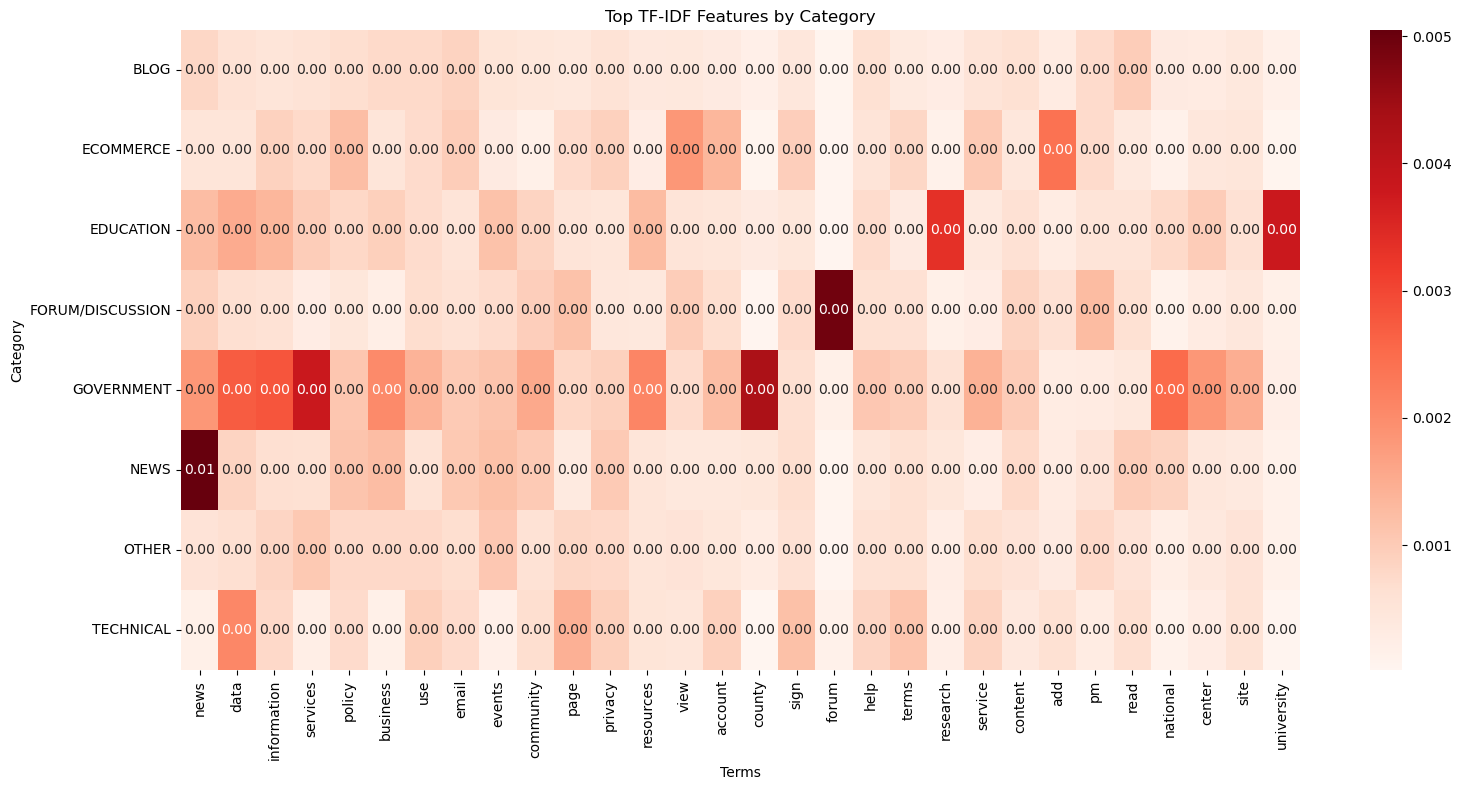

In [67]:
plt.figure(figsize=(16, 8))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Top TF-IDF Features by Category")
plt.ylabel("Category")
plt.xlabel("Terms")

plt.tight_layout()
plt.show()

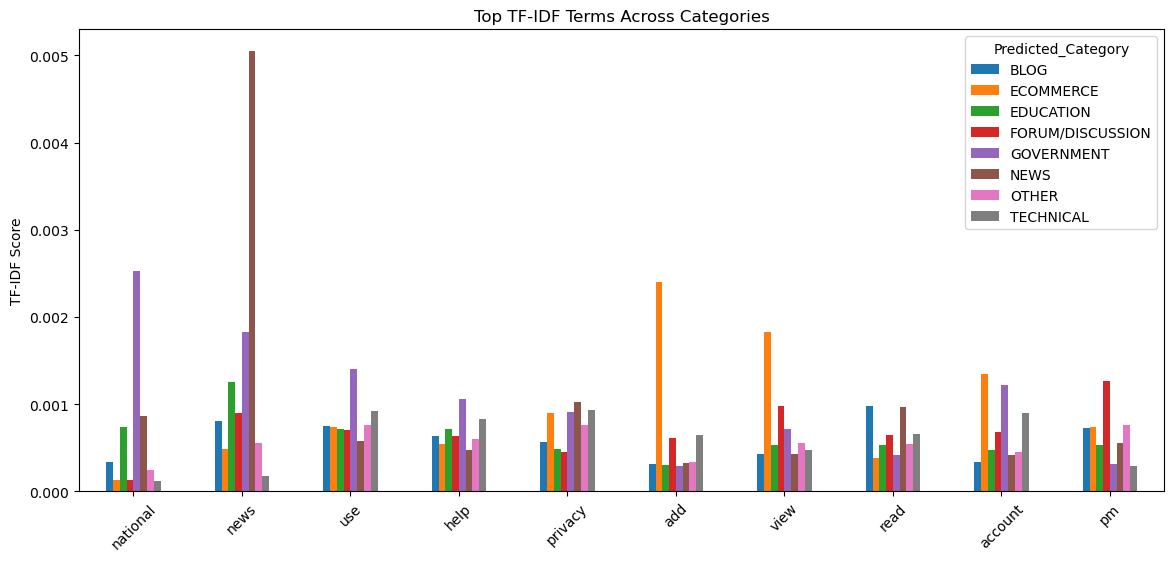

In [68]:
rand10 = plot_data.sample(n=10, axis=1)

rand10.T.plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title("Top TF-IDF Terms Across Categories")
plt.ylabel("TF-IDF Score")
plt.xticks(rotation=45)

plt.show()

### **6. Save Output as .csv**

In [69]:
output_df = pd.DataFrame()
output_df['page_id'] = data_og['page_id']
output_df['url'] = data_og['url']
output_df['predicted_label'] = complete_ftcbow_matrix_df['Predicted_Category']

output_df

,page_id,url,predicted_label
0,1,http://0769sme.org/index-16.html,EDUCATION
1,4,http://aastocks.com/en/cnhk/quote/quick-quote....,OTHER
2,6,http://ada.untergrund.net/?p=boardthread&id=18...,FORUM/DISCUSSION
3,7,http://adrienedurand.wikidot.com/blog:127,BLOG
4,8,http://afrafrontpagenews.blogspot.com/2012/03/...,NEWS
...,...,...,...
6309,8259,https://zettelfamilyfarms.ca/april-2022-newsle...,ECOMMERCE
6310,8261,https://ziloqa.net/ponds-bright-beauty-spot-le...,OTHER
6311,8262,https://ziloqa.net/understanding-bitcoin-and-i...,BLOG
6312,8264,https://zmanswoodart.com/handcrafted-wooden-fi...,ECOMMERCE


In [ ]:
output_df.to_csv('data/group_1_embeddings.csv', index=False)